<a href="https://colab.research.google.com/github/mochellez/Course_Basic-Programming-python-and-Data-Science/blob/main/sesi12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('Test.csv')
df = pd.read_csv('Train.csv')

In [ ]:
df= df.drop(columns=['Segmentation'])

In [ ]:
df= df.drop(columns=['ID'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           8068 non-null   object 
 1   Ever_Married     7928 non-null   object 
 2   Age              8068 non-null   int64  
 3   Graduated        7990 non-null   object 
 4   Profession       7944 non-null   object 
 5   Work_Experience  7239 non-null   float64
 6   Spending_Score   8068 non-null   object 
 7   Family_Size      7733 non-null   float64
 8   Var_1            7992 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 567.4+ KB


In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
df_cat= df.select_dtypes(include=['object', 'category'])

In [ ]:
df_cat

,Gender,Ever_Married,Graduated,Profession,Spending_Score,Var_1
0,Male,No,No,Healthcare,Low,Cat_4
1,Female,Yes,Yes,Engineer,Average,Cat_4
2,Female,Yes,Yes,Engineer,Low,Cat_6
3,Male,Yes,Yes,Lawyer,High,Cat_6
4,Female,Yes,Yes,Entertainment,High,Cat_6
...,...,...,...,...,...,...
8063,Male,No,No,NaN,Low,Cat_1
8064,Male,No,No,Executive,Low,Cat_4
8065,Female,No,Yes,Healthcare,Low,Cat_6
8066,Female,No,Yes,Healthcare,Low,Cat_6


In [ ]:
df_num=df.select_dtypes(include=['int','float'])

In [ ]:
df_num

,Age,Work_Experience,Family_Size
0,22,1.0,4.0
1,38,NaN,3.0
2,67,1.0,1.0
3,67,0.0,2.0
4,40,NaN,6.0
...,...,...,...
8063,22,0.0,7.0
8064,35,3.0,4.0
8065,33,1.0,1.0
8066,27,1.0,4.0


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
cat_transformer=Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                         ('onehot', OneHotEncoder(handle_unknown= 'ignore'))])
num_transformer= Pipeline(steps=[('scaler', StandardScaler()),
                          ('impute', SimpleImputer(strategy='mean'))])

In [ ]:
num_cols=df_num.columns.tolist()
print(num_cols)

['Age', 'Work_Experience', 'Family_Size']


In [ ]:
cat_cols= df_cat.columns.tolist()
print(cat_cols)

['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']


In [ ]:
preprocessor= ColumnTransformer(transformers=[('num', num_transformer, num_cols),
                                             ('cat', cat_transformer, cat_cols)])

In [ ]:
df_preprocessed= preprocessor.fit_transform(df)

In [ ]:
df_preprocessed

array([[-1.28462344e+00, -4.81916888e-01,  7.50908667e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-3.27150819e-01, -5.49666987e-17,  9.78748476e-02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.40826831e+00, -4.81916888e-01, -1.20819279e+00, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       ...,
       [-6.26361012e-01, -4.81916888e-01, -1.20819279e+00, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [-9.85413245e-01, -4.81916888e-01,  7.50908667e-01, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [-3.86992857e-01, -7.75470939e-01,  9.78748476e-02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [ ]:
new_column_names = preprocessor.get_feature_names_out()

In [ ]:
new_df= pd.DataFrame(df_preprocessed, columns=new_column_names)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

# Assuming your final preprocessed DataFrame is called `df`
# Step 1: Choose number of clusters using Elbow Method
inertia = []
silhouette_scores = []
K_range = range(2, 11)

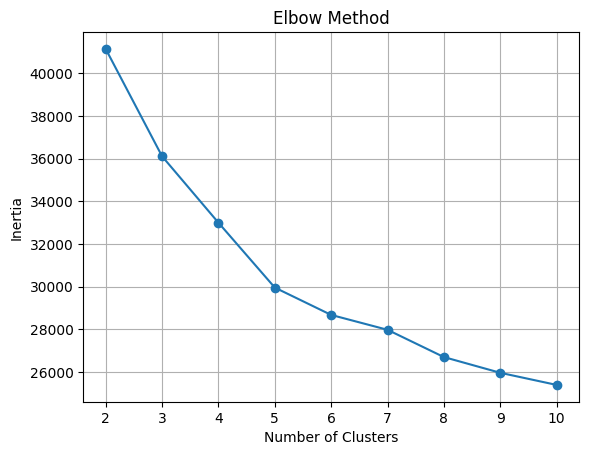

In [ ]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(new_df)
    inertia.append(kmeans.inertia_)  # Sum of squared distances
    score = silhouette_score(new_df, kmeans.labels_)
    silhouette_scores.append(score)

# Plot Elbow Curve
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [ ]:
# Select only numeric columns (one-hot encoded + scaled)
df_numeric = new_df.select_dtypes(include=['int64', 'float64'])

# Run KMeans on numeric data
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_numeric)

In [ ]:
print(df['Cluster'].value_counts())

Cluster
3    2423
2    2410
1    1724
0    1511
Name: count, dtype: int64
